In [112]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [113]:
df = pd.read_csv(r'C:\Users\Aditya\Downloads\Placement Prep\datasets\smartcart_customers.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [114]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [115]:
df['Age'] = 2026 - df['Year_Birth']
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
ref = df['Dt_Customer'].max()
df['days'] = (ref - df['Dt_Customer']).dt.days

In [116]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,247,2,9,3,4,5,0,0,59,381
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,8,7,8,2,5,7,0,0,80,19
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,24,1,2,3,13,6,0,0,45,155
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,61,2,6,5,10,3,0,0,70,156


In [117]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'days'],
      dtype='object')

In [118]:
df['Total_Spending'] = df['MntFishProducts'] + df['MntFruits'] + df['MntGoldProds'] + df['MntWines'] + df['MntMeatProducts'] + df['MntSweetProducts']
df['Children'] =  df['Kidhome'] + df['Teenhome']

In [119]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [120]:
df['Education'] = df['Education'].replace({"Graduation":'Graduate', '2n Cycle': 'Undergraduate','Basic':'Undergraduate','Master':'Postgraduate','PhD':'Postgraduate'})

In [121]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [122]:
df['Living_With'] = df['Marital_Status'].replace({'Married':'Partner','Together':'Partner','Divorced':'Alone','Widow':'Alone','Single':'Alone','Absurd':'Alone','YOLO':'Alone'})

In [123]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'days', 'Total_Spending', 'Children',
       'Living_With'],
      dtype='object')

In [124]:
cols = ['ID','Year_Birth','Marital_Status','Kidhome','Teenhome','Dt_Customer']
min_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']

tot_cols = cols + min_cols

df_cleaned = df.drop(tot_cols, axis=1)

In [125]:
df_cleaned = df_cleaned[(df_cleaned['Age'] < 90)]
df_cleaned = df_cleaned[(df_cleaned['Income'] < 600000)]

<Axes: >

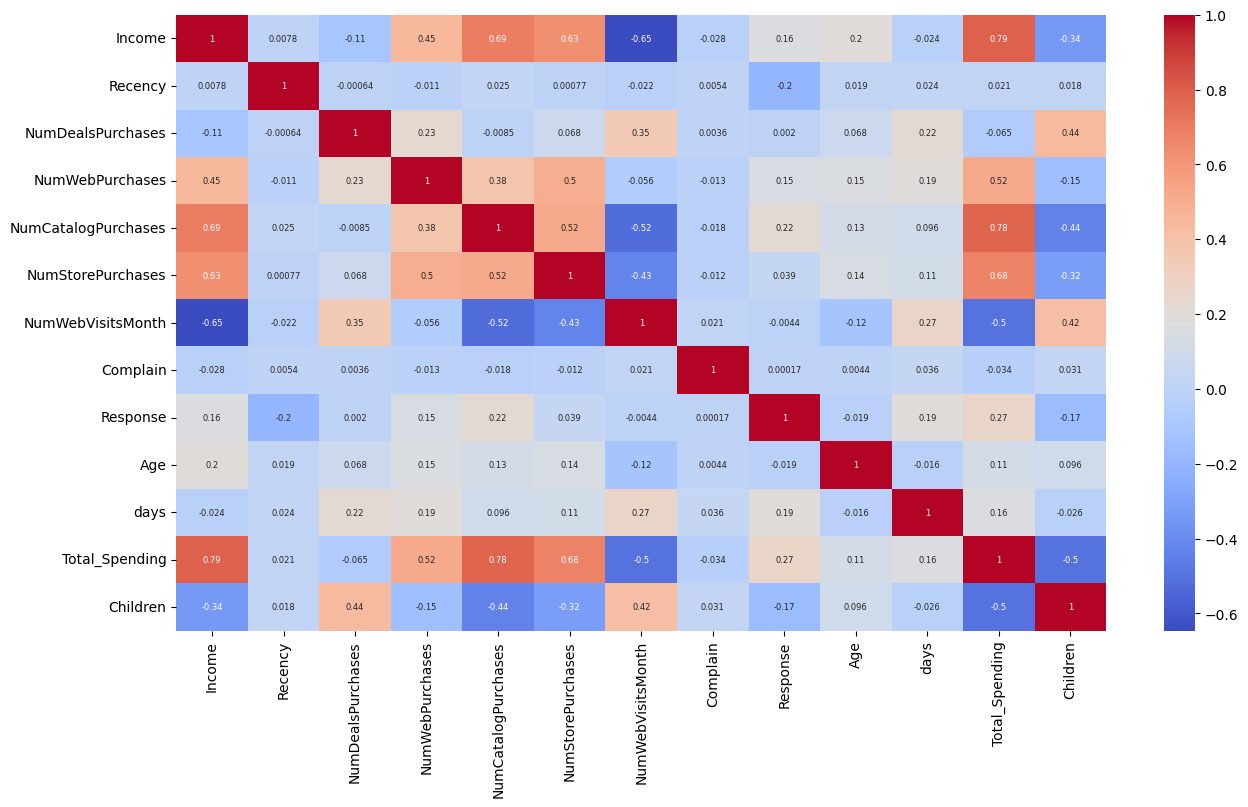

In [126]:
corr = df_cleaned.corr(numeric_only = True)

plt.figure(figsize = (15,8))
sns.heatmap(corr, annot = True, annot_kws = {'size':6}, cmap = 'coolwarm')

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
cat_cols = ['Education','Living_With']

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)

df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols),enc_df], axis = 1)
x = df_encoded
x

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,days,Total_Spending,Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0


In [128]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [129]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 3)
x_pca = pca.fit_transform(x_scaled)

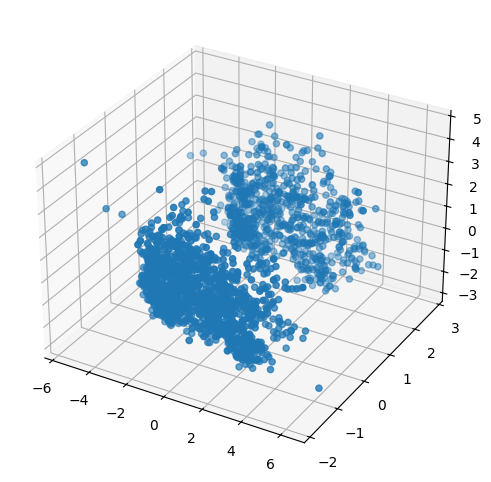

In [130]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection = "3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

In [131]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss = []

for k in range(1,11):
    km = KMeans(n_clusters = k, random_state=42)
    km.fit_predict(x_pca)
    wcss.append(km.inertia_)

knee = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
k = knee.elbow

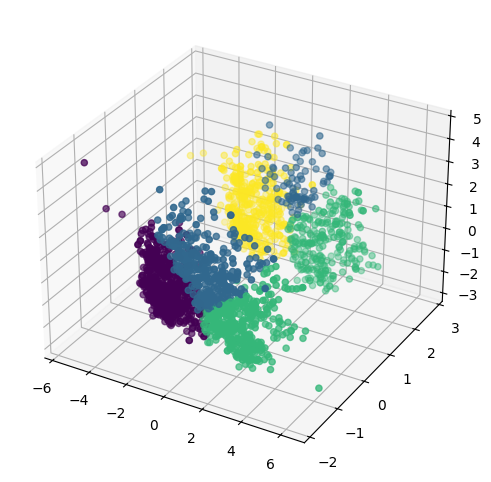

In [132]:
km = KMeans(n_clusters = 4, random_state = 42)
labels = km.fit_predict(x_pca)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection = "3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2] , c = labels)

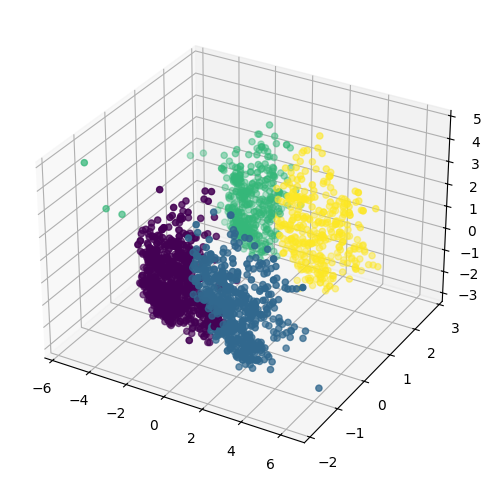

In [133]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters = 4, linkage = "ward")
labels_agg = agg.fit_predict(x_pca)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection = "3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2], c = labels_agg)

In [143]:
x['cluster'] = labels_agg

In [136]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,days,Total_Spending,Children,Living_With,cluster
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0


<Axes: xlabel='cluster', ylabel='count'>

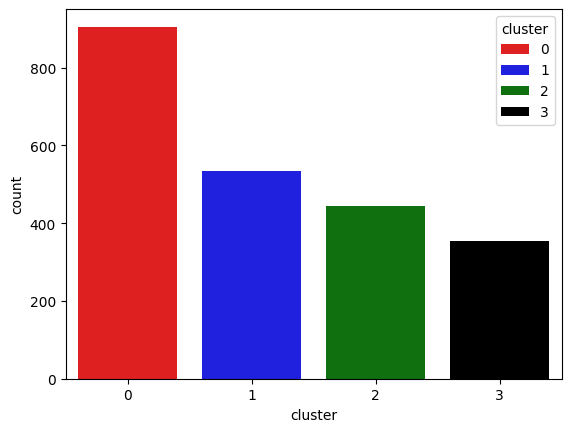

In [138]:
pal = ['red','blue','green','black']

sns.countplot(x = df_cleaned['cluster'], palette=pal, hue = df_cleaned['cluster'])

In [145]:
x.groupby('cluster').mean()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,days,Total_Spending,Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
cluster,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000
